# Seasonal Benchmark Review

This notebook presents a transparent benchmark using the saved prepared forecasting matrix. The goal is simple: understand how a strong seasonal baseline performs before comparing more complex models.

The baseline follows the project rule that forecasting should use only information available at the forecast origin. We therefore evaluate a simple month-of-year benchmark that matches each month to the same month from the previous year.



## 1. What we are benchmarking

The feature matrix and chronological splits were prepared already in the feature-engineering stage. This benchmark uses the same shared predictors and the same train, validation, and test windows so the comparison remains fair.

The seasonal benchmark is intentionally simple: it does not try to model trending dynamics or external regressors. It simply captures recurring annual seasonality in demand.



In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.forecasting_evaluation import (
    compute_residual_diagnostics,
    compute_regression_metrics,
    load_phase5_artifacts,
    save_model_run,
)
from src.models.baselines import SeasonalNaiveBaseline

FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'model_baselines'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

artifacts = load_phase5_artifacts(PROJECT_ROOT)

train_X = artifacts['train_X']
validation_X = artifacts['validation_X']
test_X = artifacts['test_X']
train_y = artifacts['train_y']
validation_y = artifacts['validation_y']
test_y = artifacts['test_y']

print('Train rows:', len(train_X))
print('Validation rows:', len(validation_X))
print('Test rows:', len(test_X))
print('Feature count:', len(train_X.columns))
print('Target:', artifacts['target_name'])



Train rows: 108
Validation rows: 24
Test rows: 36
Feature count: 28
Target: residential_water_demand_m3


## 2. Fit the seasonal benchmark

The benchmark uses the previous year's same month as the forecast. This is appropriate for recurring monthly demand behaviour in a seasonal water-usage context.



In [2]:
baseline = SeasonalNaiveBaseline(seasonal_period=12)
baseline.fit(train_y)

val_dates = validation_y.index
val_pred = baseline.predict(val_dates)

test_dates = test_y.index
test_pred = baseline.predict(test_dates)

print('Validation predictions:', len(val_pred))
print('Test predictions:', len(test_pred))

validation_metrics = compute_regression_metrics(validation_y.to_numpy(), val_pred.to_numpy())
test_metrics = compute_regression_metrics(test_y.to_numpy(), test_pred.to_numpy())

print('Validation metrics:')
print(pd.Series(validation_metrics).round(4).to_dict())
print('Test metrics:')
print(pd.Series(test_metrics).round(4).to_dict())

validation_residual_diagnostics = compute_residual_diagnostics(validation_y.to_numpy(), val_pred.to_numpy())
test_residual_diagnostics = compute_residual_diagnostics(test_y.to_numpy(), test_pred.to_numpy())
saved_paths = save_model_run(
    'seasonal_naive_baseline',
    baseline,
    {'validation': val_pred, 'test': test_pred},
    {'validation': validation_metrics, 'test': test_metrics},
    {'model': 'SeasonalNaiveBaseline', 'seasonal_period': 12, 'target': artifacts['target_name']},
    PROJECT_ROOT,
    targets={'validation': validation_y, 'test': test_y},
)
print('Residual diagnostics:')
print(pd.DataFrame({'validation': validation_residual_diagnostics, 'test': test_residual_diagnostics}))
print('Saved artifacts:', saved_paths)




Validation predictions: 24
Test predictions: 36
Validation metrics:
{'mae': 291879.1917, 'rmse': 357628.7204, 'mape': 7.2781, 'smape': 7.5328, 'r2': 0.6797}
Test metrics:
{'mae': 433726.9361, 'rmse': 526201.042, 'mape': 9.9152, 'smape': 10.5585, 'r2': 0.4673}


In [3]:
summary = pd.DataFrame({
    'split': ['validation', 'test'],
    'rows': [len(validation_y), len(test_y)],
    'mae': [validation_metrics['mae'], test_metrics['mae']],
    'rmse': [validation_metrics['rmse'], test_metrics['rmse']],
    'smape': [validation_metrics['smape'], test_metrics['smape']],
    'r2': [validation_metrics['r2'], test_metrics['r2']],
})

display(summary)

residual_summary = pd.DataFrame({'validation': validation_residual_diagnostics, 'test': test_residual_diagnostics})
display(residual_summary.round(3))




,split,rows,mae,rmse,smape,r2
0,validation,24,291879.191667,357628.720362,7.532828,0.679694
1,test,36,433726.936111,526201.042035,10.558542,0.467279


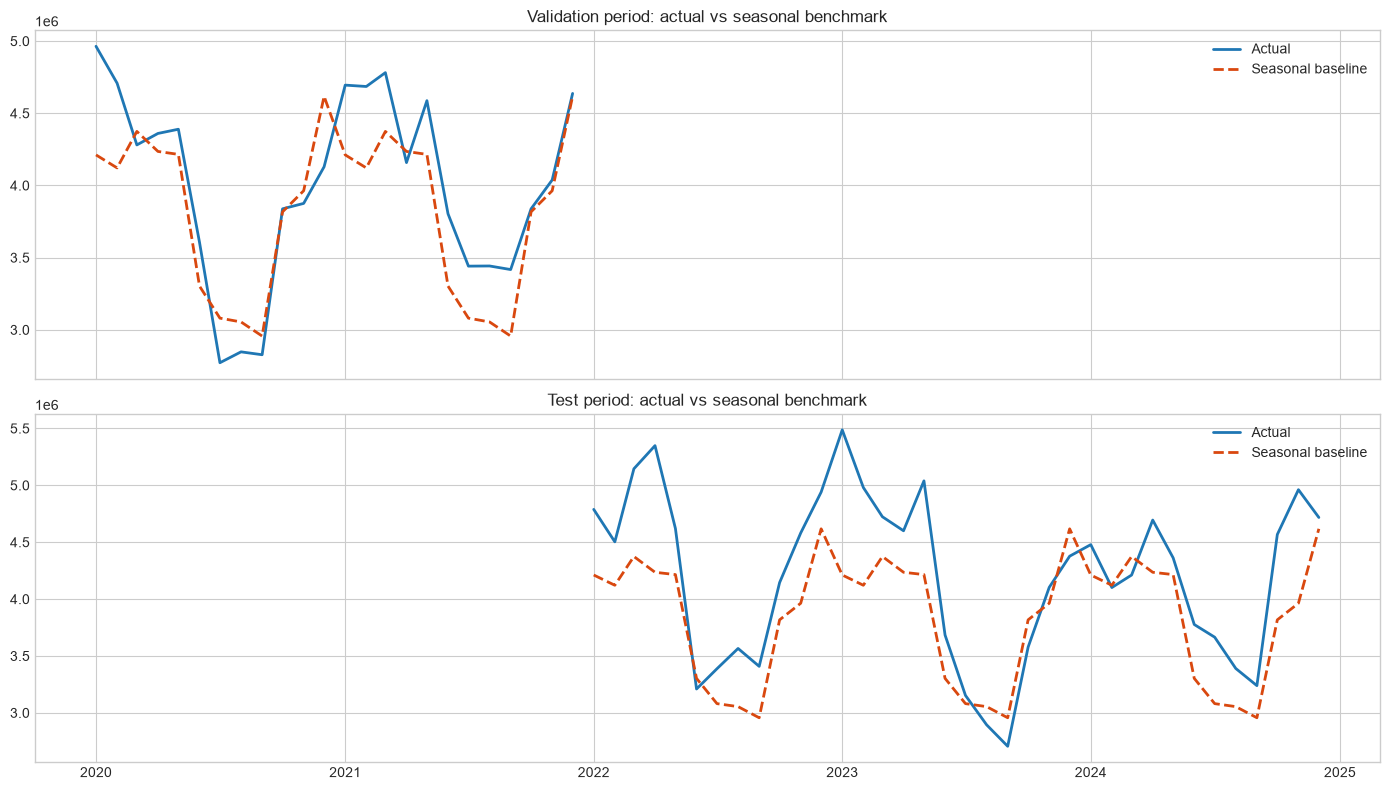

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(validation_y.index, validation_y.values, label='Actual', color='#1f77b4', linewidth=2)
axes[0].plot(val_pred.index, val_pred.values, label='Seasonal baseline', color='#d9480f', linewidth=2, linestyle='--')
axes[0].set_title('Validation period: actual vs seasonal benchmark')
axes[0].legend()

axes[1].plot(test_y.index, test_y.values, label='Actual', color='#1f77b4', linewidth=2)
axes[1].plot(test_pred.index, test_pred.values, label='Seasonal baseline', color='#d9480f', linewidth=2, linestyle='--')
axes[1].set_title('Test period: actual vs seasonal benchmark')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_seasonal_baseline_comparison.png', dpi=180, bbox_inches='tight')
plt.show()



## 3. Interpretation

This benchmark tells us how much signal the model must beat. If a seasonal baseline performs well, it suggests strong recurring month-to-month demand structure. If more advanced models improve materially on it, then the additional model complexity is justified.

The benchmark is intentionally transparent and reproducible. It also acts as the starting point for the later model comparison and selection work.



In [5]:
benchmark_summary = {
    'target': artifacts['target_name'],
    'validation_mae': round(validation_metrics['mae'], 3),
    'validation_rmse': round(validation_metrics['rmse'], 3),
    'validation_smape': round(validation_metrics['smape'], 3),
    'validation_r2': round(validation_metrics['r2'], 3),
    'test_mae': round(test_metrics['mae'], 3),
    'test_rmse': round(test_metrics['rmse'], 3),
    'test_smape': round(test_metrics['smape'], 3),
    'test_r2': round(test_metrics['r2'], 3),
}

print(json.dumps(benchmark_summary, indent=2))



{
  "target": "residential_water_demand_m3",
  "validation_mae": 291879.192,
  "validation_rmse": 357628.72,
  "validation_smape": 7.533,
  "validation_r2": 0.68,
  "test_mae": 433726.936,
  "test_rmse": 526201.042,
  "test_smape": 10.559,
  "test_r2": 0.467
}
